<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 3, Rollout Recursivo**

Importamos las librerías necesarias

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import urllib.request
from scipy.io import wavfile
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import Audio, display

Fijamos las semillas para reproducibilidad

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

Descargamos y preparamos el audio

In [ ]:
URL = "https://raw.githubusercontent.com/pytorch/audio/main/test/torchaudio_unittest/assets/steam-train-whistle-daniel_simon.wav"
urllib.request.urlretrieve(URL, "tren.wav")
sr, w = wavfile.read("tren.wav")
audio = w.mean(axis=1).astype(np.float32) # convertimos a mono
audio = audio[::4] # submuestreamos a 11,025 Hz
sr = sr // 4
audio = audio / np.abs(audio).max()   # normalizamos a [-1, 1]

Construimos las ventanas de train y test (split temporal, H=1 para entrenar a un paso)

In [ ]:
L = 160
n_tr = int(len(audio) * 0.8)
X_tr, y_tr, X_te, y_te = [], [], [], []
for i in range(0, n_tr - L, 4):
    X_tr.append(audio[i : i + L]); y_tr.append(audio[i + L : i + L + 1])
for i in range(n_tr - L, len(audio) - L - 1, 4):
    X_te.append(audio[i : i + L]); y_te.append(audio[i + L : i + L + 1])
X_tr = torch.tensor(np.array(X_tr)).unsqueeze(-1); y_tr = torch.tensor(np.array(y_tr))
X_te = torch.tensor(np.array(X_te)).unsqueeze(-1); y_te = torch.tensor(np.array(y_te))

Entrenamos una GRU a un paso (el rollout la usará para predecir muchos)

In [ ]:
rnn = nn.GRU(1, 64, batch_first=True) # creamos la celda GRU
cabeza = nn.Linear(64, 1) # definimos la cabeza de salida
parametros = list(rnn.parameters()) + list(cabeza.parameters())
optimizador = torch.optim.Adam(parametros, lr=3e-3)  # definimos el optimizador
lotes = DataLoader(TensorDataset(X_tr, y_tr), batch_size=256, shuffle=True)
for epoca in range(5):   # entrenamos 5 épocas
    for xb, yb in lotes:
        optimizador.zero_grad() # limpiamos los gradientes
        salida, _ = rnn(xb) # realizamos el forward
        perdida = ((cabeza(salida[:, -1]) - yb)**2).mean()  # calculamos el MSE
        perdida.backward()    # propagamos el gradiente
        nn.utils.clip_grad_norm_(parametros, 1.0)  # aplicamos clipping
        optimizador.step()  # actualizamos los pesos

Verificamos que el modelo es bueno a un paso (le gana al naive)

In [ ]:
with torch.no_grad():
    salida, _ = rnn(X_te)
    rmse_1paso = ((cabeza(salida[:, -1]) - y_te)**2).mean().sqrt().item()

naive = ((X_te[:, -1, 0:1] - y_te)**2).mean().sqrt().item()

print(f"a un paso — naive: {naive:.4f} | GRU: {rmse_1paso:.4f}  (la GRU gana)")

a un paso — naive: 0.0796 | GRU: 0.0311  (la GRU gana)


Realizamos el rollout: el modelo continúa el audio solo durante medio segundo

In [ ]:
n_gen = sr // 2   # cuántas muestras generar
with torch.no_grad():
    semilla = X_te[0].unsqueeze(0)  # 15 ms reales como semilla
    salida, h = rnn(semilla)  # procesamos la semilla una vez
    x_t = cabeza(salida[:, -1]).reshape(1, 1, 1)  # obtenemos la primera predicción
    generado = [x_t.item()]
    for paso in range(n_gen - 1):
        salida, h = rnn(x_t, h)  # continuamos desde h (el estado se arrastra)
        x_t = cabeza(salida[:, -1]).reshape(1, 1, 1)  # la predicción se vuelve el siguiente input
        generado.append(x_t.item())
generado = np.array(generado)

Tomamos la continuación real para comparar

In [ ]:
real = audio[n_tr : n_tr + n_gen]

Graficamos: el modelo bueno a un paso colapsa a los pocos milisegundos

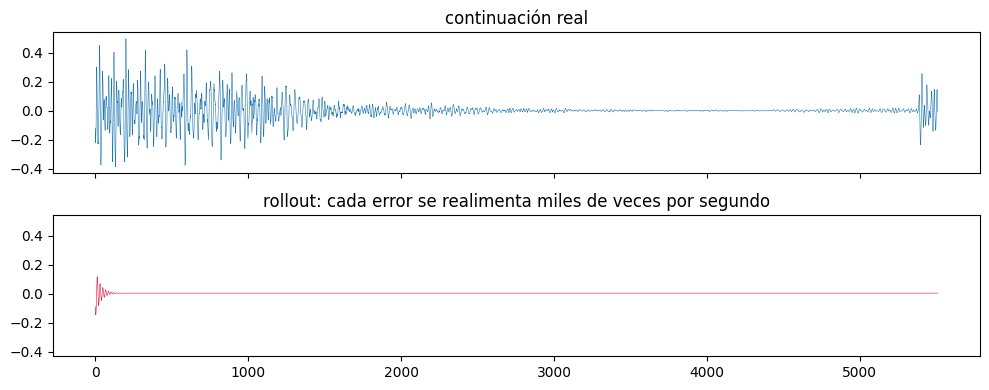

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 4), sharex=True, sharey=True)
ax[0].plot(real, lw=0.4)
ax[0].set_title("continuación real")
ax[1].plot(generado, lw=0.4, color="crimson")
ax[1].set_title("rollout: cada error se realimenta miles de veces por segundo")
plt.tight_layout()
plt.show()

Estadísticas

In [ ]:
print(f"amplitud (std) — real: {real.std():.3f} | generado: {generado.std():.6f}")
print(f"Rango generado: [{generado.min():.6f}, {generado.max():.6f}]")

amplitud (std) — real: 0.071 | generado: 0.006783
Rango generado: [-0.145626, 0.116934]


Audio real

In [ ]:
display(Audio(real / np.max(np.abs(real)), rate=sr))

Audio generado

In [ ]:
# Quitamos componente DC
gen_audio = generado - generado.mean()

# Amplificamos únicamente para escuchar
ganancia = 50

gen_audio = gen_audio * ganancia

# Evitamos saturación
gen_audio = np.clip(gen_audio, -1, 1)

display(Audio(gen_audio.astype(np.float32), rate=sr))